# 🔬 Breast Cancer Histopathological Image Classification
## Using CNN and Transfer Learning

### *Custom CNN vs VGG16*

---

| Field | Details |
|---|---|
| **Student Name** | Sneha Chaurasia |
| **PRN** | 202401110046 |
| **Class / Division** | CSE-AIML / A |
| **Subject** | Generative AI LAB |
| **Practical No.** | 01 |
| **Date** | 20/08/20206 |

---


## 📄 2. Research Paper Information

This practical is inspired by the following peer-reviewed research paper:

| Parameter | Details |
|---|---|
| **Paper Title** | Breast cancer histology images classification: Training from scratch or transfer learning? |
| **Authors** | Shallu Sharma, Rajesh Mehra |
| **Journal** | ICT Express |
| **Year** | 2018 |
| **DOI** | [10.1016/j.icte.2018.10.007](https://doi.org/10.1016/j.icte.2018.10.007) |
| **Link** | https://www.sciencedirect.com/science/article/pii/S2405959518304934 |
| **Dataset used in paper** | BreaKHis (full dataset, multiple magnifications) |
| **Models used in paper** | VGG16, VGG19, ResNet50 (as fixed feature extractors + fine-tuned, with logistic regression / SVM classifiers) |
| **Research Question** | Does transfer learning outperform training a CNN from scratch for breast histopathology classification? |
| **Key Reported Result** | Fine-tuned VGG16 + logistic regression achieved **92.60% accuracy** on a 90%-10% train-test split |


### 🔑 Paper Methodology vs Our Implementation
| | Paper Methodology | Our Implementation |
|---|---|---|
| Dataset | Full BreaKHis (multiple magnifications) | BreaKHis **400X subset** (Kaggle) |
| Models | VGG16, VGG19, ResNet50 | Custom CNN **and** VGG16 |
| Classifier head | Logistic Regression / SVM on extracted features | Dense + Sigmoid layers trained end-to-end |
| Comparison | Train-from-scratch vs transfer learning (per model) | Custom CNN (from scratch) **vs** VGG16 (transfer learning + fine-tuning) |

> ⚠️ We do **not** claim to reproduce the paper's exact results. Our goal is to follow the same *core research question* on a smaller, practical dataset.


## 🧩 3. Problem Statement

Breast cancer is one of the most common cancers, and histopathological image analysis (microscopic examination of tissue) is a key step in diagnosis. Manual analysis by pathologists is time-consuming and subject to inter-observer variability.

Convolutional Neural Networks (CNNs) have shown the ability to automatically learn discriminative visual features directly from histopathological images, without hand-crafted feature engineering. However, training a deep CNN **from scratch** typically requires large labelled datasets, which are difficult to obtain in the medical domain.

**Transfer learning** offers an alternative: reusing a CNN (such as VGG16) pretrained on a large natural-image dataset (ImageNet) and adapting it to the target medical imaging task.

This notebook investigates and empirically compares:
1. A **Custom CNN** trained from scratch on the BreaKHis 400X benign/malignant classification task.
2. A **VGG16 transfer-learning** model (feature extraction + fine-tuning) on the same task.

> This is an **academic/educational comparison** and does **not** constitute a clinically validated diagnostic tool.


## 🎯 4. Objectives

1. To preprocess breast histopathological images (BreaKHis 400X) for deep learning.
2. To perform binary classification of images into **Benign** vs **Malignant**.
3. To design and train a **Custom CNN** from scratch.
4. To implement **VGG16** with ImageNet pretrained weights for transfer learning.
5. To **fine-tune** the top convolutional layers of VGG16 on the target dataset.
6. To compare both models using **accuracy, precision, recall, F1-score, ROC-AUC, training time, and model complexity**.
7. To relate our experimental findings back to the selected research paper.


## ⚙️ Setup: Imports, Seeds & GPU Check

Run this cell first. It imports all libraries used throughout the notebook, sets a fixed random seed for reproducibility, and checks whether a GPU is available.


In [ ]:
# Core imports
import os, sys, time, glob, random, shutil, zipfile, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- GPU check ----
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"✅ GPU is available: {gpu_devices}")
else:
    print("⚠️ No GPU found. Go to Runtime -> Change runtime type -> GPU for faster training.")

print("TensorFlow version:", tf.__version__)

IMG_SIZE = 224
BATCH_SIZE = 32


✅ GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.20.0


## 📦 5. Dataset Description

**Dataset name:** BreaKHis 400X (partial subset)
**Source:** Kaggle
**URL:** https://www.kaggle.com/datasets/forderation/breakhis-400x
**Magnification:** 400X only
**Classes:** Benign, Malignant

### Background
The original **BreaKHis** (Breast Cancer Histopathological Image Classification) dataset was collected in partnership with the P&D Laboratory, Brazil, and contains microscopic images of breast tumor tissue at four magnification levels (40X, 100X, 200X, 400X). The Kaggle dataset used here is a **partial subset containing only the 400X magnification images**, already organized into training and testing folders — it is **not** the complete original BreaKHis dataset.

### Loading the dataset

In [ ]:
# ===== Direct Kaggle Import via kagglehub =====

!pip install -q kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("forderation/breakhis-400x")

print("Path to dataset files:", path)

DATA_ROOT = path
print("✅ Dataset ready at:", DATA_ROOT)

100%|██████████| 803M/803M [00:10<00:00, 82.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/forderation/breakhis-400x/versions/1
✅ Dataset ready at: /root/.cache/kagglehub/datasets/forderation/breakhis-400x/versions/1


### Automatic Directory Structure Detection

We must **not** assume folder names. The cell below walks the extracted dataset directory, prints the folder tree, and automatically detects the training directory, testing directory, and the benign/malignant class folders within each.


In [ ]:
def print_tree(root, max_depth=3):
    """Print a directory tree up to max_depth levels for inspection."""
    root = pathlib.Path(root)
    if not root.exists():
        print(f"⚠️ Path does not exist yet: {root}\n"
              f"   (Run the Kaggle download cells above first.)")
        return
    for path in sorted(root.rglob('*')):
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue
        indent = "    " * (depth - 1)
        marker = "📁" if path.is_dir() else "🖼️"
        print(f"{indent}{marker} {path.name}")

print_tree(DATA_ROOT, max_depth=3)


📁 BreaKHis 400X
    📁 test
        📁 benign
        📁 malignant
    📁 train
        📁 benign
        📁 malignant


In [ ]:
def find_split_and_class_dirs(root):
    """
    Automatically detect train/test directories and benign/malignant
    class subfolders anywhere under `root`, without assuming exact names.
    Returns a dict: {'train': {'benign': path, 'malignant': path},
                      'test':  {'benign': path, 'malignant': path}}
    """
    root = pathlib.Path(root)
    result = {"train": {}, "test": {}}

    all_dirs = [p for p in root.rglob('*') if p.is_dir()]

    def classify_split(name):
        n = name.lower()
        if "train" in n:
            return "train"
        if "test" in n or "val" in n:
            return "test"
        return None

    def classify_class(name):
        n = name.lower()
        if "benign" in n or n.startswith("b_") or n == "0":
            return "benign"
        if "malignant" in n or n.startswith("m_") or n == "1":
            return "malignant"
        return None

    # Pass 1: look for class folders and infer split from their parent path
    for d in all_dirs:
        cls = classify_class(d.name)
        if cls is None:
            continue
        # walk up parents to find which split this belongs to
        split = None
        for parent in d.parents:
            s = classify_split(parent.name)
            if s:
                split = s
                break
        if split is None:
            # fallback: check the class folder's own path string
            path_str = str(d).lower()
            split = "train" if "train" in path_str else ("test" if ("test" in path_str or "val" in path_str) else None)
        if split and cls not in result[split]:
            # prefer folders that actually contain image files
            n_images = len([f for f in d.iterdir() if f.suffix.lower() in
                             ('.png', '.jpg', '.jpeg', '.tif', '.bmp')])
            if n_images > 0:
                result[split][cls] = d

    return result

detected = find_split_and_class_dirs(DATA_ROOT)
print("Auto-detected dataset structure:")
for split, classes in detected.items():
    for cls, path in classes.items():
        print(f"  {split:5s} / {cls:10s} -> {path}")

if not (detected.get("train") and detected.get("test")):
    print("\n⚠️ Could not fully auto-detect the structure. "
          "Please inspect the printed tree above and set the paths manually "
          "in the TRAIN_DIRS / TEST_DIRS variables below.")

TRAIN_DIRS = detected.get("train", {})
TEST_DIRS = detected.get("test", {})


Auto-detected dataset structure:
  train / malignant  -> /root/.cache/kagglehub/datasets/forderation/breakhis-400x/versions/1/BreaKHis 400X/train/malignant
  train / benign     -> /root/.cache/kagglehub/datasets/forderation/breakhis-400x/versions/1/BreaKHis 400X/train/benign
  test  / malignant  -> /root/.cache/kagglehub/datasets/forderation/breakhis-400x/versions/1/BreaKHis 400X/test/malignant
  test  / benign     -> /root/.cache/kagglehub/datasets/forderation/breakhis-400x/versions/1/BreaKHis 400X/test/benign


### Dataset Statistics (auto-counted)

The cell below **counts** the actual number of images (never invented) in each split/class and displays them in a summary table.


In [ ]:
def count_images(folder):
    if folder is None or not pathlib.Path(folder).exists():
        return 0
    exts = ('.png', '.jpg', '.jpeg', '.tif', '.bmp')
    return len([f for f in pathlib.Path(folder).iterdir() if f.suffix.lower() in exts])

stats = []
for split, classes in [("Train", TRAIN_DIRS), ("Test", TEST_DIRS)]:
    for cls_name in ["benign", "malignant"]:
        n = count_images(classes.get(cls_name))
        stats.append({"Split": split, "Class": cls_name.capitalize(), "Image Count": n})

df_stats = pd.DataFrame(stats)
total_train = df_stats[df_stats.Split == "Train"]["Image Count"].sum()
total_test = df_stats[df_stats.Split == "Test"]["Image Count"].sum()

summary_row = pd.DataFrame([
    {"Split": "Train", "Class": "TOTAL", "Image Count": total_train},
    {"Split": "Test", "Class": "TOTAL", "Image Count": total_test},
])
df_stats_full = pd.concat([df_stats, summary_row], ignore_index=True)
df_stats_full


,Split,Class,Image Count
0,Train,Benign,371
1,Train,Malignant,777
2,Test,Benign,176
3,Test,Malignant,369
4,Train,TOTAL,1148
5,Test,TOTAL,545


## 📊 6. Dataset Visualization

We visualize:
1. Class distribution (bar chart)
2. A grid of random sample images (benign + malignant)
3. Image dimension statistics


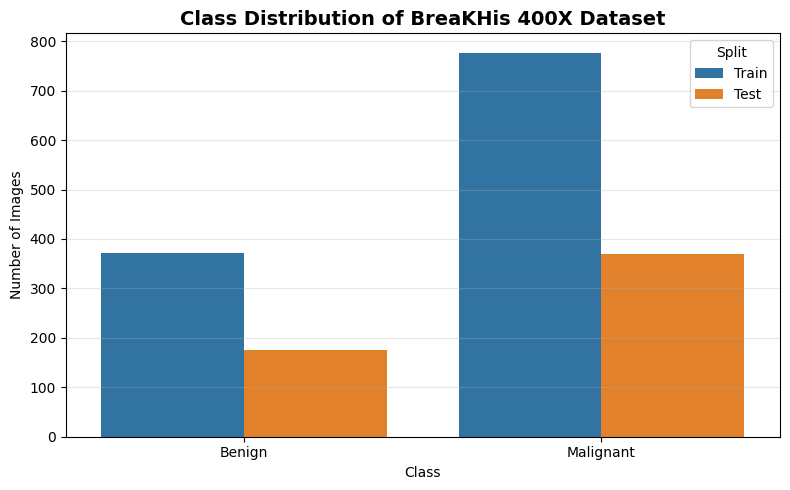

In [ ]:
# 1. Class distribution bar chart
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = df_stats[df_stats["Image Count"] > 0]
sns.barplot(data=plot_df, x="Class", y="Image Count", hue="Split", ax=ax)
ax.set_title("Class Distribution of BreaKHis 400X Dataset", fontsize=14, fontweight='bold')
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


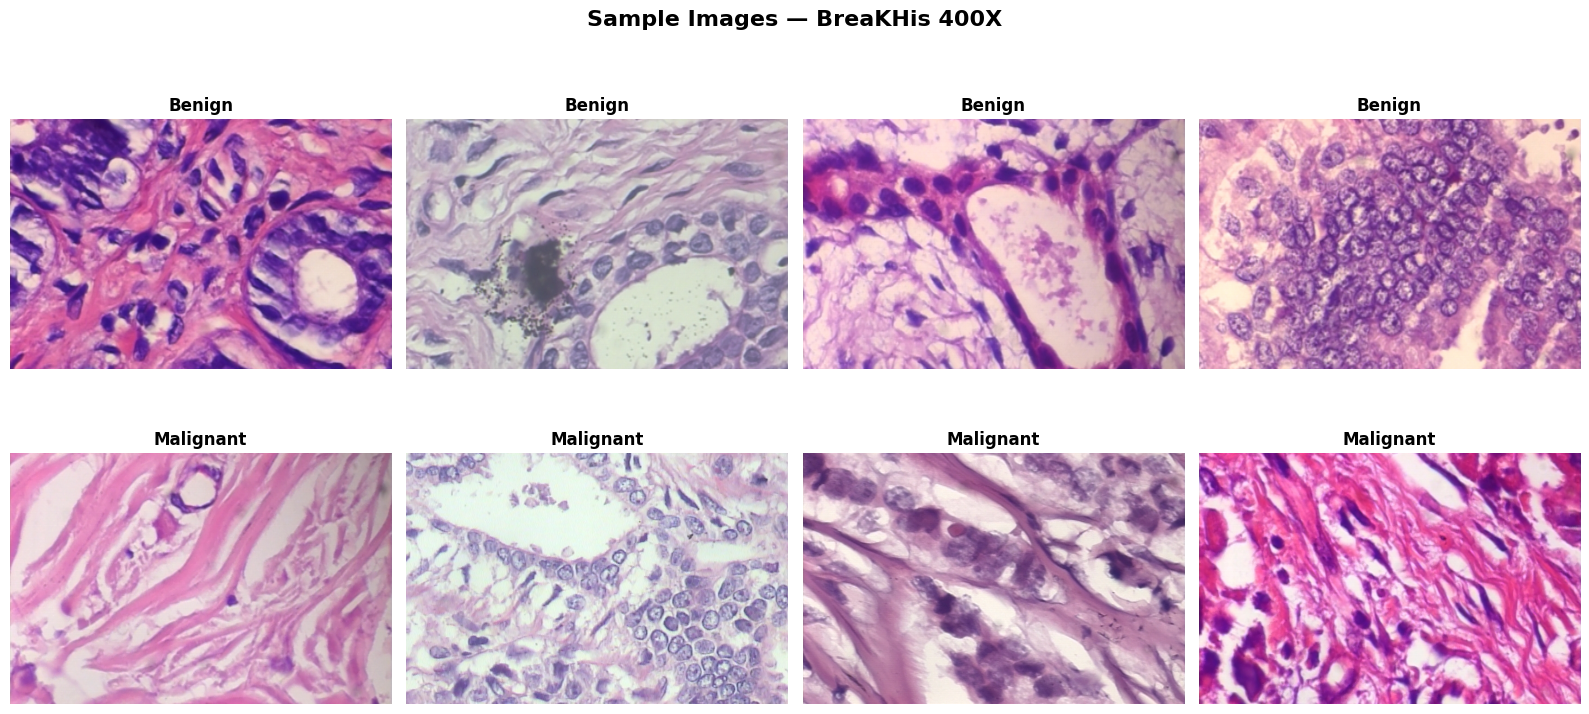

In [ ]:
# 2. Random sample image grid (at least 8 images, class labelled)
def sample_images(folder, n=4):
    if folder is None or not pathlib.Path(folder).exists():
        return []
    exts = ('.png', '.jpg', '.jpeg', '.tif', '.bmp')
    files = [f for f in pathlib.Path(folder).iterdir() if f.suffix.lower() in exts]
    return random.sample(files, min(n, len(files)))

benign_samples = sample_images(TRAIN_DIRS.get("benign"), 4)
malignant_samples = sample_images(TRAIN_DIRS.get("malignant"), 4)
all_samples = [(p, "Benign") for p in benign_samples] + [(p, "Malignant") for p in malignant_samples]

if all_samples:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for ax, (path, label) in zip(axes.flat, all_samples):
        img = load_img(path)
        ax.imshow(img)
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.axis('off')
    fig.suptitle("Sample Images — BreaKHis 400X", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No sample images found yet — run the dataset download cells first.")


In [ ]:
# 3. Image dimension analysis
def get_dims(folder, n=30):
    dims = []
    samples = sample_images(folder, n)
    for p in samples:
        with load_img(p) as img:
            dims.append(img.size)  # (width, height)
    return dims

dims = get_dims(TRAIN_DIRS.get("benign"), 15) + get_dims(TRAIN_DIRS.get("malignant"), 15)
if dims:
    widths, heights = zip(*dims)
    print(f"Sampled {len(dims)} images")
    print(f"Width  -> min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.1f}")
    print(f"Height -> min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}")
else:
    print("⚠️ No images available to analyze yet.")


Sampled 30 images
Width  -> min: 700, max: 700, mean: 700.0
Height -> min: 460, max: 460, mean: 460.0


## 🛠️ 7. Data Preprocessing

All images are resized to **224 × 224 × 3** (VGG16's expected ImageNet input size) so that the **same input pipeline works for both models**.

We use `tf.keras.preprocessing.image.ImageDataGenerator` with:
- `rescale=1./255` for the **Custom CNN** (simple 0–1 normalization)
- `preprocess_input` (VGG16-specific, ImageNet mean-subtraction) for **VGG16**

This keeps preprocessing consistent with each model's expectations and avoids applying normalization twice.


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Custom CNN preprocessing: simple rescale to [0,1]
cnn_train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
cnn_test_datagen = ImageDataGenerator(rescale=1./255)

# VGG16 preprocessing: use the official VGG16 preprocess_input (ImageNet mean subtraction)
vgg_train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input, validation_split=0.2)
vgg_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

print("Preprocessing pipelines configured for 224x224x3 input.")


Preprocessing pipelines configured for 224x224x3 input.


## 🔁 8. Data Augmentation

Augmentation is applied **only to the training data** to improve generalization, and is kept **moderate** to avoid distorting genuine histopathology patterns (e.g. no extreme color/shape distortion).

Transformations used:
- Random horizontal flip
- Small rotation (±15°)
- Small zoom (±10%)
- Small width/height shift (±10%)

Validation and test data are **not** augmented — only rescaled/preprocessed.


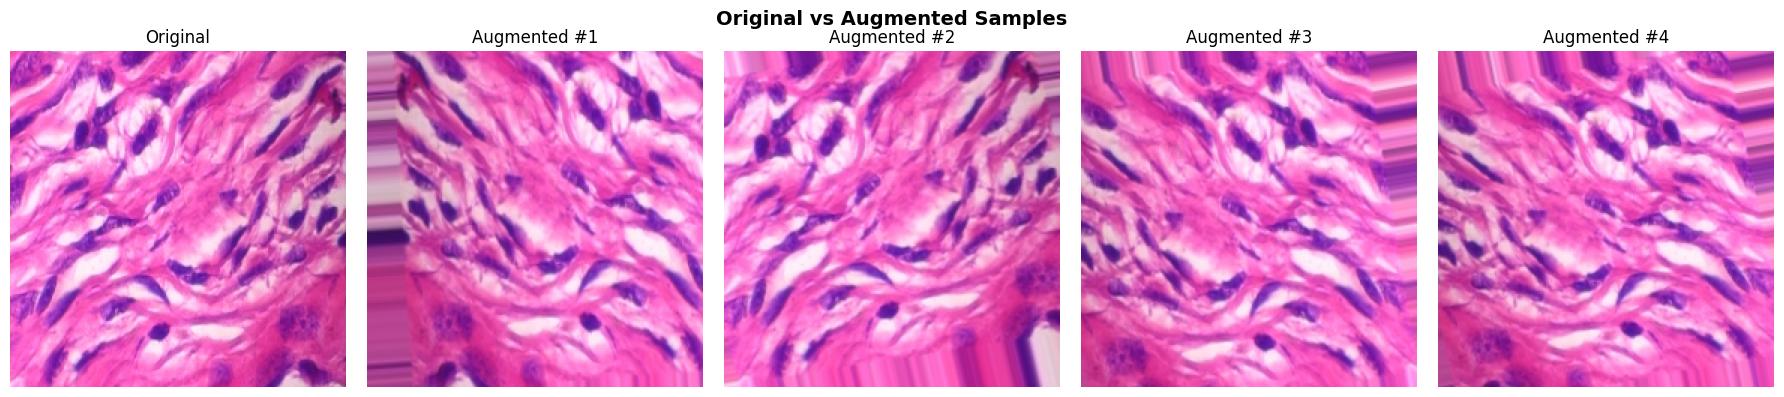

In [ ]:
# Augmented generator used ONLY for the training split
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
)

# Visualize: original vs augmented for one sample image
sample_path = None
for p in [TRAIN_DIRS.get("benign"), TRAIN_DIRS.get("malignant")]:
    s = sample_images(p, 1)
    if s:
        sample_path = s[0]
        break

if sample_path is not None:
    img = load_img(sample_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img)
    arr_batch = np.expand_dims(arr, 0)

    aug_iter = augmented_datagen.flow(arr_batch, batch_size=1)
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes[0].imshow(arr.astype('uint8'))
    axes[0].set_title("Original")
    axes[0].axis('off')
    for i in range(1, 5):
        aug_img = next(aug_iter)[0]
        axes[i].imshow(aug_img)
        axes[i].set_title(f"Augmented #{i}")
        axes[i].axis('off')
    fig.suptitle("Original vs Augmented Samples", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No sample image available yet for augmentation preview.")


## ✂️ 9. Train / Validation / Test Split

The Kaggle dataset already provides separate **training** and **testing** directories, so we do **not** recombine and re-split everything.

- **Training (80%)** and **Validation (20%)** are derived from the original *training* directory via `validation_split=0.2` (stratified per-class by folder structure).
- **Testing** uses the original, untouched Kaggle *test* directory — it is never used during training or hyperparameter tuning.

A fixed random seed (`SEED=42`) is used for reproducibility.

> ⚠️ **Patient-level data leakage note:** BreaKHis filenames often encode a patient/slide identifier. If such identifiers are present, images from the *same patient* could appear in both train and test splits, which can optimistically bias results. This notebook uses the split **as provided by the Kaggle dataset** and does **not** implement patient-wise re-splitting — this is a known limitation, discussed further in Section 25.


In [ ]:
def build_flow(datagen, dir_map, subset=None, shuffle=True):
    """Build a flow_from_directory-compatible generator given detected class dirs.
    Since benign/malignant may not share one parent folder, we point
    flow_from_directory at their common parent when possible, otherwise
    we build a manual file-list based generator."""
    paths = [p for p in dir_map.values() if p is not None]
    if not paths:
        return None
    parent_dirs = set(p.parent for p in paths)
    if len(parent_dirs) == 1:
        common_parent = list(parent_dirs)[0]
        return datagen.flow_from_directory(
            common_parent,
            target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE,
            class_mode='binary',
            classes=['benign', 'malignant'] if all(
                (common_parent / c).exists() for c in ['benign', 'malignant']) else None,
            subset=subset,
            shuffle=shuffle,
            seed=SEED,
        )
    return None  # fallback handled below if folder layout is irregular

train_gen_cnn = build_flow(cnn_train_datagen, TRAIN_DIRS, subset='training')
val_gen_cnn = build_flow(cnn_train_datagen, TRAIN_DIRS, subset='validation', shuffle=False)
test_gen_cnn = build_flow(cnn_test_datagen, TEST_DIRS, subset=None, shuffle=False)

train_gen_vgg = build_flow(vgg_train_datagen, TRAIN_DIRS, subset='training')
val_gen_vgg = build_flow(vgg_train_datagen, TRAIN_DIRS, subset='validation', shuffle=False)
test_gen_vgg = build_flow(vgg_test_datagen, TEST_DIRS, subset=None, shuffle=False)

train_gen_aug = build_flow(augmented_datagen, TRAIN_DIRS, subset='training')

if train_gen_cnn is not None:
    print(f"Training samples:   {train_gen_cnn.samples}")
    print(f"Validation samples: {val_gen_cnn.samples}")
    print(f"Testing samples:    {test_gen_cnn.samples}")
    print("Class indices:", train_gen_cnn.class_indices)
else:
    print("⚠️ Benign/Malignant folders were not found under a common parent directory.\n"
          "   Inspect the printed tree in Section 5 and adjust TRAIN_DIRS/TEST_DIRS, "
          "   or reorganize folders into <split>/benign, <split>/malignant before proceeding.")


Found 919 images belonging to 2 classes.
Found 229 images belonging to 2 classes.
Found 545 images belonging to 2 classes.
Found 919 images belonging to 2 classes.
Found 229 images belonging to 2 classes.
Found 545 images belonging to 2 classes.
Found 919 images belonging to 2 classes.
Training samples:   919
Validation samples: 229
Testing samples:    545
Class indices: {'benign': 0, 'malignant': 1}


## 🧱 10. Custom CNN Architecture

We build a CNN **from scratch** (no pretrained weights) with 4 convolutional blocks, batch normalization, global average pooling, and a dense classification head.


In [ ]:
def build_custom_cnn(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid'),
    ], name="Custom_CNN")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    return model

custom_cnn = build_custom_cnn((IMG_SIZE, IMG_SIZE, 3))
custom_cnn.summary()

total_params = custom_cnn.count_params()
trainable_params = sum(np.prod(v.shape) for v in custom_cnn.trainable_weights)
non_trainable_params = total_params - trainable_params
print(f"\nTotal parameters:        {total_params:,}")
print(f"Trainable parameters:    {trainable_params:,.0f}")
print(f"Non-trainable parameters:{non_trainable_params:,.0f}")


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)


Total parameters:        423,361
Trainable parameters:    422,401
Non-trainable parameters:960


## 🏋️ 11. Custom CNN Training

Trained with `EarlyStopping` (restores best weights) and `ReduceLROnPlateau`. Training time is measured with Python's `time` module — never hard-coded.


In [ ]:
EPOCHS_CNN = 10

callbacks_cnn = [
    # EarlyStopping removed so training always completes all epochs
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

start_time = time.time()

history_cnn = custom_cnn.fit(
    train_gen_cnn,
    validation_data=val_gen_cnn,
    epochs=EPOCHS_CNN,
    callbacks=callbacks_cnn,
)

cnn_training_time = time.time() - start_time

best_val_acc_cnn = max(history_cnn.history['val_accuracy'])
best_val_loss_cnn = min(history_cnn.history['val_loss'])

print(f"\n⏱️ Custom CNN training time: {cnn_training_time:.2f} seconds")
print(f"✅ Best validation accuracy: {best_val_acc_cnn:.4f}")
print(f"✅ Best validation loss:     {best_val_loss_cnn:.4f}")

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 577ms/step - accuracy: 0.8509 - loss: 0.3676 - val_accuracy: 0.6769 - val_loss: 0.9491 - learning_rate: 5.0000e-04
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 566ms/step - accuracy: 0.8629 - loss: 0.3247 - val_accuracy: 0.6769 - val_loss: 1.2577 - learning_rate: 5.0000e-04
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 543ms/step - accuracy: 0.8901 - loss: 0.2697 - val_accuracy: 0.6769 - val_loss: 1.0508 - learning_rate: 5.0000e-04
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 530ms/step - accuracy: 0.9021 - loss: 0.2713 - val_accuracy: 0.6769 - val_loss: 1.0031 - learning_rate: 5.0000e-04
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 526ms/step - accuracy: 0.9108 - loss: 0.2355 - val_accuracy: 0.6769 - val_loss: 1.0488 - learning_rate: 2.5000e-04
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 526ms/step - accuracy: 0.9184 - loss: 0.2195 - val_accuracy: 0.6769 - val_loss: 1.0546 - learning_rate: 2.5000e-04
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 665ms/step - acc

## 📈 12. Custom CNN Evaluation

Evaluated strictly on the **untouched test set** — never on training data.


In [ ]:
test_gen_cnn.reset()
y_true_cnn = test_gen_cnn.classes
y_prob_cnn = custom_cnn.predict(test_gen_cnn, verbose=1).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

acc_cnn = accuracy_score(y_true_cnn, y_pred_cnn)
prec_cnn = precision_score(y_true_cnn, y_pred_cnn)
rec_cnn = recall_score(y_true_cnn, y_pred_cnn)
f1_cnn = f1_score(y_true_cnn, y_pred_cnn)
try:
    auc_cnn = roc_auc_score(y_true_cnn, y_prob_cnn)
except ValueError:
    auc_cnn = float('nan')

print(f"Custom CNN — Test Accuracy:  {acc_cnn:.4f}")
print(f"Custom CNN — Test Precision: {prec_cnn:.4f}")
print(f"Custom CNN — Test Recall:    {rec_cnn:.4f}")
print(f"Custom CNN — Test F1-score:  {f1_cnn:.4f}")
print(f"Custom CNN — Test ROC-AUC:   {auc_cnn:.4f}")

print("\nClassification Report — Custom CNN")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=['Benign', 'Malignant']))


18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 376ms/step
Custom CNN — Test Accuracy:  0.6899
Custom CNN — Test Precision: 0.6931
Custom CNN — Test Recall:    0.9729
Custom CNN — Test F1-score:  0.8095
Custom CNN — Test ROC-AUC:   0.6167

Classification Report — Custom CNN
              precision    recall  f1-score   support

      Benign       0.63      0.10      0.17       176
   Malignant       0.69      0.97      0.81       369

    accuracy                           0.69       545
   macro avg       0.66      0.53      0.49       545
weighted avg       0.67      0.69      0.60       545



## 📉 13. Custom CNN Training Graphs


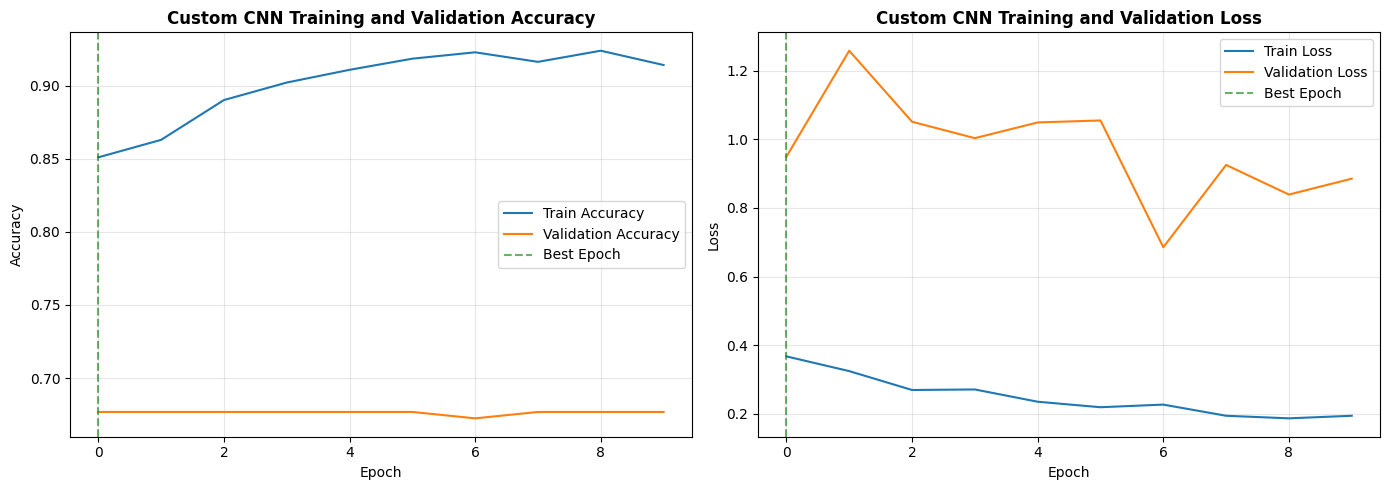

In [ ]:
best_epoch_cnn = int(np.argmax(history_cnn.history['val_accuracy']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
axes[0].axvline(best_epoch_cnn, color='green', linestyle='--', alpha=0.6, label='Best Epoch')
axes[0].set_title("Custom CNN Training and Validation Accuracy", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_cnn.history['loss'], label='Train Loss')
axes[1].plot(history_cnn.history['val_loss'], label='Validation Loss')
axes[1].axvline(best_epoch_cnn, color='green', linestyle='--', alpha=0.6, label='Best Epoch')
axes[1].set_title("Custom CNN Training and Validation Loss", fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 🧮 14. Custom CNN Confusion Matrix

The confusion matrix shows how many Benign/Malignant test images were correctly vs incorrectly classified:
- **True Positive (TP):** Malignant correctly predicted as Malignant
- **True Negative (TN):** Benign correctly predicted as Benign
- **False Positive (FP):** Benign incorrectly predicted as Malignant
- **False Negative (FN):** Malignant incorrectly predicted as Benign (most costly error in a medical context)


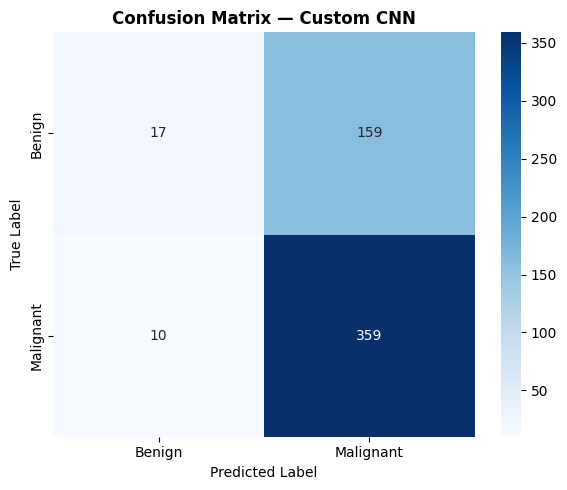

True Negative (Benign->Benign):     17
False Positive (Benign->Malignant): 159
False Negative (Malignant->Benign): 10
True Positive (Malignant->Malignant): 359


In [ ]:
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
tn_cnn, fp_cnn, fn_cnn, tp_cnn = cm_cnn.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], ax=ax)
ax.set_title("Confusion Matrix — Custom CNN", fontweight='bold')
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

print(f"True Negative (Benign->Benign):     {tn_cnn}")
print(f"False Positive (Benign->Malignant): {fp_cnn}")
print(f"False Negative (Malignant->Benign): {fn_cnn}")
print(f"True Positive (Malignant->Malignant): {tp_cnn}")


## 🧠 15. VGG16 Transfer Learning

**VGG16** is a 16-layer deep CNN introduced by Simonyan & Zisserman (2014), pretrained on **ImageNet** (1.4M images, 1000 classes). Its convolutional layers have learned rich, general-purpose visual features (edges, textures, shapes, object parts) that transfer well to many downstream vision tasks.

We selected VGG16 because it is the model that achieved the paper's **best reported result (92.60%)**, making it a natural choice for direct comparison in our implementation.

We load VGG16 **without its top classification layers** (`include_top=False`) and attach our own classification head for benign vs malignant.


In [ ]:
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

def build_vgg_model(base_model):
    base_model.trainable = False  # freeze for feature extraction phase
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs, outputs, name="VGG16_Transfer")
    return model

vgg_model = build_vgg_model(base_vgg)
vgg_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 🧊 16. Feature Extraction (Phase 1)

In this phase, the VGG16 convolutional base is **frozen** (its ImageNet weights are not updated). Only the newly added classification head is trained.

> *"Feature extraction reuses representations learned from ImageNet while training a new classifier for the target task."*


In [ ]:
vgg_total_params = vgg_model.count_params()
vgg_trainable_params = sum(np.prod(v.shape) for v in vgg_model.trainable_weights)
vgg_frozen_params = vgg_total_params - vgg_trainable_params

print(f"Total parameters:     {vgg_total_params:,}")
print(f"Trainable parameters: {vgg_trainable_params:,.0f}")
print(f"Frozen parameters:    {vgg_frozen_params:,.0f}")

vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

EPOCHS_FEATURE = 8
callbacks_fe = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
]

start_time = time.time()

history_vgg_feature = vgg_model.fit(
    train_gen_vgg,
    validation_data=val_gen_vgg,
    epochs=EPOCHS_FEATURE,
    callbacks=callbacks_fe,
)

feature_extraction_time = time.time() - start_time
print(f"\n⏱️ Feature extraction training time: {feature_extraction_time:.2f} seconds")


Total parameters:     14,780,481
Trainable parameters: 65,793
Frozen parameters:    14,714,688
Epoch 1/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.6899 - loss: 1.1618 - val_accuracy: 0.7162 - val_loss: 0.9674 - learning_rate: 0.0010
Epoch 2/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 601ms/step - accuracy: 0.8259 - loss: 0.4966 - val_accuracy: 0.7424 - val_loss: 0.5877 - learning_rate: 0.0010
Epoch 3/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 579ms/step - accuracy: 0.8672 - loss: 0.3577 - val_accuracy: 0.7424 - val_loss: 0.5985 - learning_rate: 0.0010
Epoch 4/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 599ms/step - accuracy: 0.8770 - loss: 0.3173 - val_accuracy: 0.7729 - val_loss: 0.5488 - learning_rate: 0.0010
Epoch 5/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 618ms/step - accuracy: 0.9042 - loss: 0.2549 - val_accuracy: 0.7817 - val_loss: 0.5447 - learning_rate: 0.0010
Epoch 6/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 588ms/step - accuracy: 0.9162 - loss: 0.2162 - val_accuracy: 0.7467 - val_loss: 0.5268 - learning_rate: 0.0

## 🔓 17. Fine-Tuning (Phase 2)

We now **unfreeze only the last few convolutional layers** of VGG16 (the last convolutional block, `block5`), keeping earlier layers frozen. This lets the top-level features adapt slightly to histopathology images while preserving general low/mid-level ImageNet features. A **very small learning rate (1e-5)** is used to avoid destroying the pretrained weights.


In [ ]:
frozen_before = sum(1 for l in base_vgg.layers if not l.trainable)
trainable_before = sum(1 for l in base_vgg.layers if l.trainable)
print(f"Before fine-tuning -> Frozen layers: {frozen_before}, Trainable layers: {trainable_before}")

# Unfreeze the base model, then re-freeze everything except the last conv block
base_vgg.trainable = True
FINE_TUNE_FROM_LAYER_NAME_PREFIX = "block5"  # only unfreeze the last VGG16 conv block

for layer in base_vgg.layers:
    layer.trainable = layer.name.startswith(FINE_TUNE_FROM_LAYER_NAME_PREFIX)

frozen_after = sum(1 for l in base_vgg.layers if not l.trainable)
trainable_after = sum(1 for l in base_vgg.layers if l.trainable)
print(f"After fine-tuning  -> Frozen layers: {frozen_after}, Trainable layers: {trainable_after}")

vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # very small LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy'],
)


Before fine-tuning -> Frozen layers: 19, Trainable layers: 0
After fine-tuning  -> Frozen layers: 15, Trainable layers: 4


## 🏋️ 18. VGG16 Training (Fine-Tuning Phase)

Training continues from the feature-extraction weights. We keep the feature-extraction and fine-tuning histories **separate** so their curves can be shown distinctly in Section 20.


In [ ]:
EPOCHS_FINETUNE = 12
callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8),
]

start_time = time.time()

history_vgg_finetune = vgg_model.fit(
    train_gen_vgg,
    validation_data=val_gen_vgg,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks_ft,
)

fine_tune_time = time.time() - start_time
vgg_training_time = feature_extraction_time + fine_tune_time

best_val_acc_vgg = max(
    max(history_vgg_feature.history['val_accuracy']),
    max(history_vgg_finetune.history['val_accuracy']),
)
best_val_loss_vgg = min(
    min(history_vgg_feature.history['val_loss']),
    min(history_vgg_finetune.history['val_loss']),
)

print(f"\n⏱️ Fine-tuning time:        {fine_tune_time:.2f} seconds")
print(f"⏱️ Total VGG16 training time: {vgg_training_time:.2f} seconds "
      f"(feature extraction + fine-tuning)")
print(f"✅ Best validation accuracy: {best_val_acc_vgg:.4f}")
print(f"✅ Best validation loss:     {best_val_loss_vgg:.4f}")


Epoch 1/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 793ms/step - accuracy: 0.9423 - loss: 0.1710 - val_accuracy: 0.7860 - val_loss: 0.5818 - learning_rate: 1.0000e-05
Epoch 2/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 591ms/step - accuracy: 0.9782 - loss: 0.0786 - val_accuracy: 0.7642 - val_loss: 0.6489 - learning_rate: 1.0000e-05
Epoch 3/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 616ms/step - accuracy: 0.9739 - loss: 0.0731 - val_accuracy: 0.7686 - val_loss: 0.6117 - learning_rate: 1.0000e-05
Epoch 4/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 585ms/step - accuracy: 0.9837 - loss: 0.0593 - val_accuracy: 0.7642 - val_loss: 0.6901 - learning_rate: 1.0000e-05
Epoch 5/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 585ms/step - accuracy: 0.9902 - loss: 0.0399 - val_accuracy: 0.7817 - val_loss: 0.6525 - learning_rate: 5.0000e-06
Epoch 6/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 582ms/step - accuracy: 0.9924 - loss: 0.0385 - val_accuracy: 0.7773 - val_loss: 0.6525 - learning_rate: 5.0000e-06

⏱️ Fine-tuning time:        115.70 seconds
⏱️ Total VGG16

## 📈 19. VGG16 Evaluation

Evaluated on the same untouched test set as the Custom CNN, for a fair comparison.


In [ ]:
test_gen_vgg.reset()
y_true_vgg = test_gen_vgg.classes
y_prob_vgg = vgg_model.predict(test_gen_vgg, verbose=1).ravel()
y_pred_vgg = (y_prob_vgg >= 0.5).astype(int)

acc_vgg = accuracy_score(y_true_vgg, y_pred_vgg)
prec_vgg = precision_score(y_true_vgg, y_pred_vgg)
rec_vgg = recall_score(y_true_vgg, y_pred_vgg)
f1_vgg = f1_score(y_true_vgg, y_pred_vgg)
try:
    auc_vgg = roc_auc_score(y_true_vgg, y_prob_vgg)
except ValueError:
    auc_vgg = float('nan')

print(f"VGG16 — Test Accuracy:  {acc_vgg:.4f}")
print(f"VGG16 — Test Precision: {prec_vgg:.4f}")
print(f"VGG16 — Test Recall:    {rec_vgg:.4f}")
print(f"VGG16 — Test F1-score:  {f1_vgg:.4f}")
print(f"VGG16 — Test ROC-AUC:   {auc_vgg:.4f}")

print("\nClassification Report — VGG16")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=['Benign', 'Malignant']))


18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 535ms/step
VGG16 — Test Accuracy:  0.8917
VGG16 — Test Precision: 0.9058
VGG16 — Test Recall:    0.9377
VGG16 — Test F1-score:  0.9214
VGG16 — Test ROC-AUC:   0.9429

Classification Report — VGG16
              precision    recall  f1-score   support

      Benign       0.86      0.80      0.83       176
   Malignant       0.91      0.94      0.92       369

    accuracy                           0.89       545
   macro avg       0.88      0.87      0.87       545
weighted avg       0.89      0.89      0.89       545



## 📉 20. VGG16 Training Graphs

Feature-extraction and fine-tuning phases are shown as two connected segments on the same timeline.


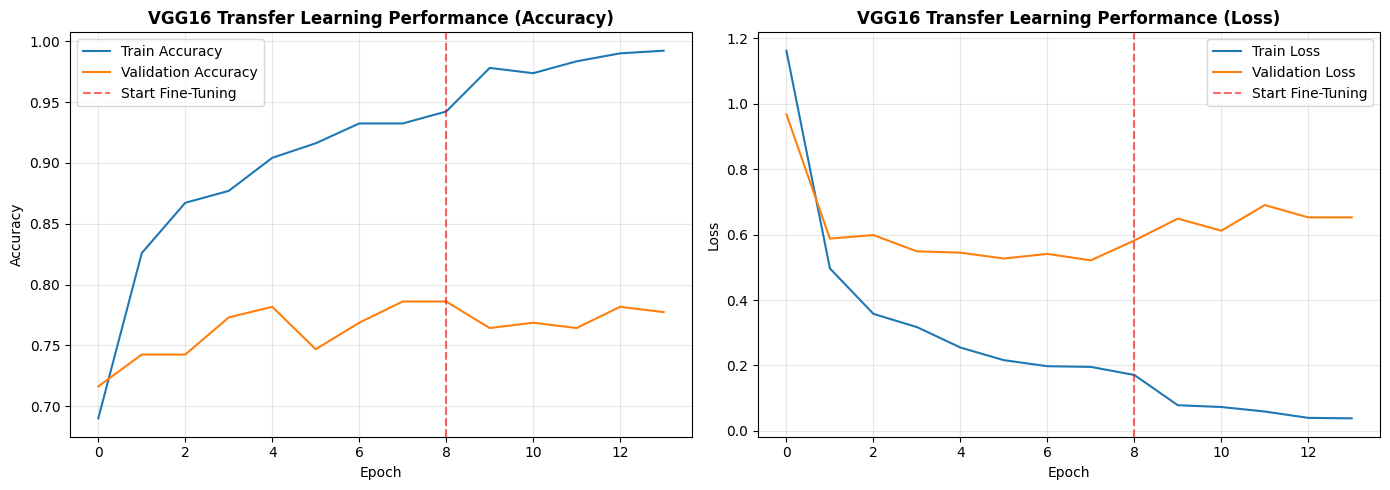

In [ ]:
acc_fe = history_vgg_feature.history['accuracy']
val_acc_fe = history_vgg_feature.history['val_accuracy']
loss_fe = history_vgg_feature.history['loss']
val_loss_fe = history_vgg_feature.history['val_loss']

acc_ft = history_vgg_finetune.history['accuracy']
val_acc_ft = history_vgg_finetune.history['val_accuracy']
loss_ft = history_vgg_finetune.history['loss']
val_loss_ft = history_vgg_finetune.history['val_loss']

full_acc = acc_fe + acc_ft
full_val_acc = val_acc_fe + val_acc_ft
full_loss = loss_fe + loss_ft
full_val_loss = val_loss_fe + val_loss_ft
switch_epoch = len(acc_fe)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(full_acc, label='Train Accuracy')
axes[0].plot(full_val_acc, label='Validation Accuracy')
axes[0].axvline(switch_epoch, color='red', linestyle='--', alpha=0.6, label='Start Fine-Tuning')
axes[0].set_title("VGG16 Transfer Learning Performance (Accuracy)", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(full_loss, label='Train Loss')
axes[1].plot(full_val_loss, label='Validation Loss')
axes[1].axvline(switch_epoch, color='red', linestyle='--', alpha=0.6, label='Start Fine-Tuning')
axes[1].set_title("VGG16 Transfer Learning Performance (Loss)", fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 🧮 21. VGG16 Confusion Matrix


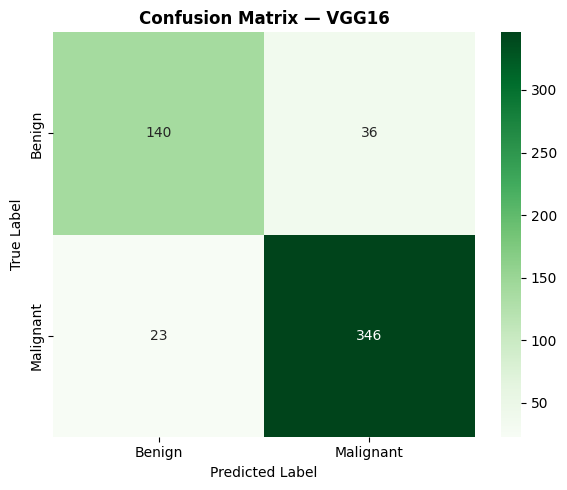

True Negative (Benign->Benign):     140
False Positive (Benign->Malignant): 36
False Negative (Malignant->Benign): 23
True Positive (Malignant->Malignant): 346


In [ ]:
cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)
tn_vgg, fp_vgg, fn_vgg, tp_vgg = cm_vgg.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], ax=ax)
ax.set_title("Confusion Matrix — VGG16", fontweight='bold')
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

print(f"True Negative (Benign->Benign):     {tn_vgg}")
print(f"False Positive (Benign->Malignant): {fp_vgg}")
print(f"False Negative (Malignant->Benign): {fn_vgg}")
print(f"True Positive (Malignant->Malignant): {tp_vgg}")


## 🗺️ 22. Feature Map Visualization

To understand what VGG16 "sees" at different depths, we visualize intermediate feature maps for one sample test image at an **early**, **middle**, and **deeper** convolutional layer:

- **Early layers** (e.g. `block1_conv2`): detect edges and textures
- **Middle layers** (e.g. `block3_conv3`): detect patterns and shapes
- **Deeper layers** (e.g. `block5_conv3`): detect higher-level, more abstract visual representations


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step


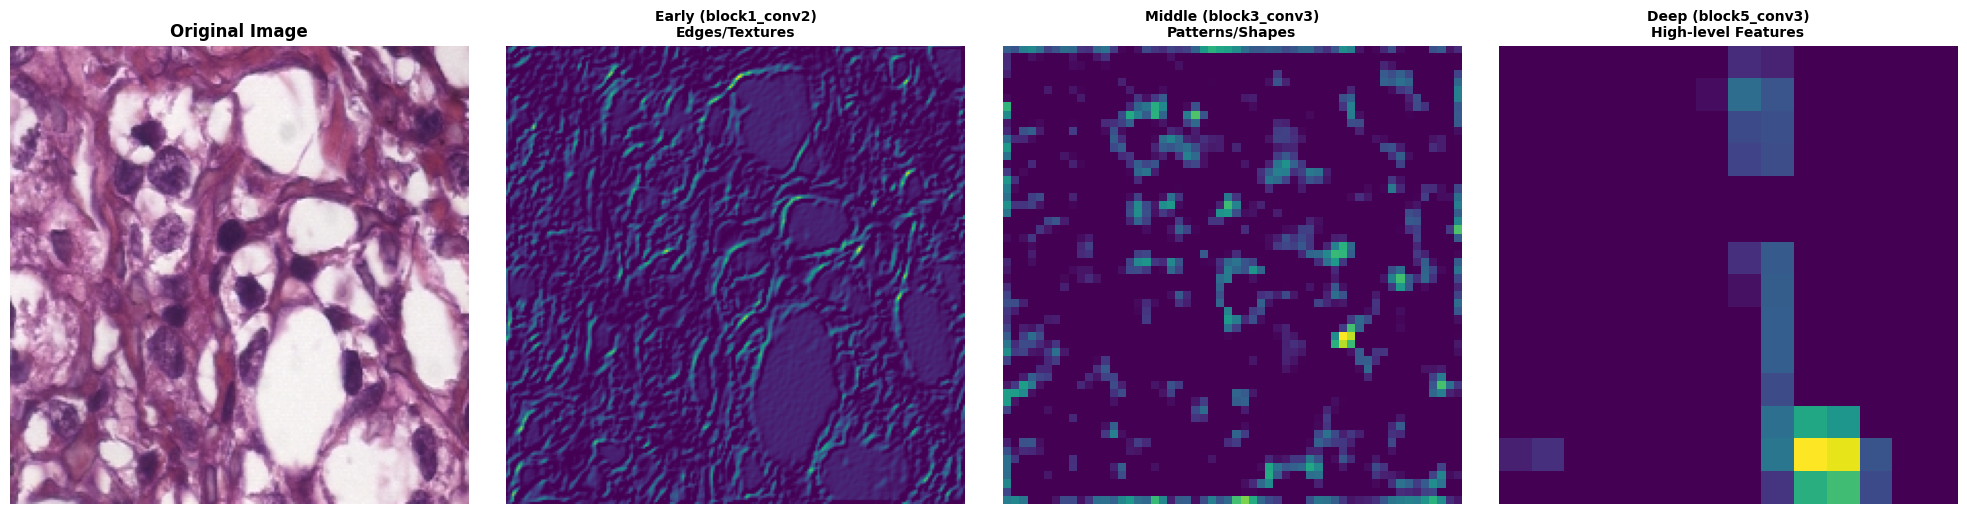

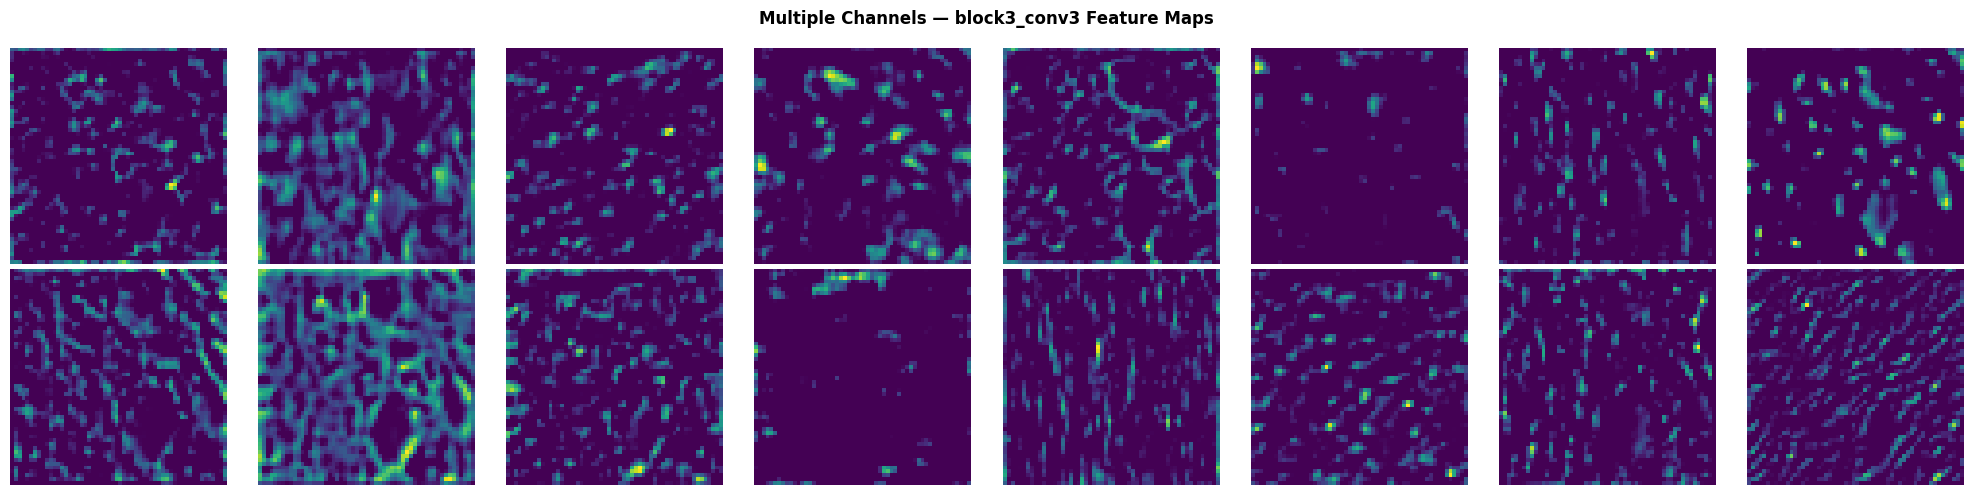

In [ ]:
layer_names = ['block1_conv2', 'block3_conv3', 'block5_conv3']
layer_outputs = [base_vgg.get_layer(name).output for name in layer_names]
feature_map_model = keras.Model(inputs=base_vgg.input, outputs=layer_outputs)

# Pick one sample image from the test set
sample_test_path = None
for cls_dir in TEST_DIRS.values():
    s = sample_images(cls_dir, 1)
    if s:
        sample_test_path = s[0]
        break

if sample_test_path is not None:
    img = load_img(sample_test_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img)
    arr_pre = preprocess_input(np.expand_dims(arr.copy(), 0))

    feature_maps = feature_map_model.predict(arr_pre)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(arr.astype('uint8'))
    axes[0].set_title("Original Image", fontweight='bold')
    axes[0].axis('off')

    depth_labels = ['Early (block1_conv2)\nEdges/Textures',
                     'Middle (block3_conv3)\nPatterns/Shapes',
                     'Deep (block5_conv3)\nHigh-level Features']

    for i, (fmap, label) in enumerate(zip(feature_maps, depth_labels)):
        # show first channel as representative feature map
        axes[i + 1].imshow(fmap[0, :, :, 0], cmap='viridis')
        axes[i + 1].set_title(label, fontweight='bold', fontsize=10)
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

    # Also show a grid of multiple channels from the middle layer
    mid_fmap = feature_maps[1][0]
    n_channels = min(16, mid_fmap.shape[-1])
    fig, axes = plt.subplots(2, 8, figsize=(20, 5))
    for i, ax in enumerate(axes.flat):
        if i < n_channels:
            ax.imshow(mid_fmap[:, :, i], cmap='viridis')
        ax.axis('off')
    fig.suptitle("Multiple Channels — block3_conv3 Feature Maps", fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No test image available yet for feature map visualization.")


## ⚖️ 23. Custom CNN vs VGG16 — Comparison

All values below are pulled directly from the actual experimental results computed above — nothing is hard-coded.


In [ ]:
comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC",
               "Training Time (s)", "Total Parameters", "Trainable Parameters"],
    "Custom CNN": [acc_cnn, prec_cnn, rec_cnn, f1_cnn, auc_cnn,
                   cnn_training_time, total_params, trainable_params],
    "VGG16 Transfer Learning": [acc_vgg, prec_vgg, rec_vgg, f1_vgg, auc_vgg,
                                 vgg_training_time, vgg_total_params, vgg_trainable_params],
}
df_comparison = pd.DataFrame(comparison_data)
df_comparison


,Metric,Custom CNN,VGG16 Transfer Learning
0,Accuracy,0.689908,8.917431e-01
1,Precision,0.693050,9.057592e-01
2,Recall,0.972900,9.376694e-01
3,F1-score,0.809470,9.214381e-01
4,ROC-AUC,0.616701,9.428893e-01
5,Training Time (s),160.798336,2.848381e+02
6,Total Parameters,423361.000000,1.478048e+07
7,Trainable Parameters,422401.000000,6.579300e+04


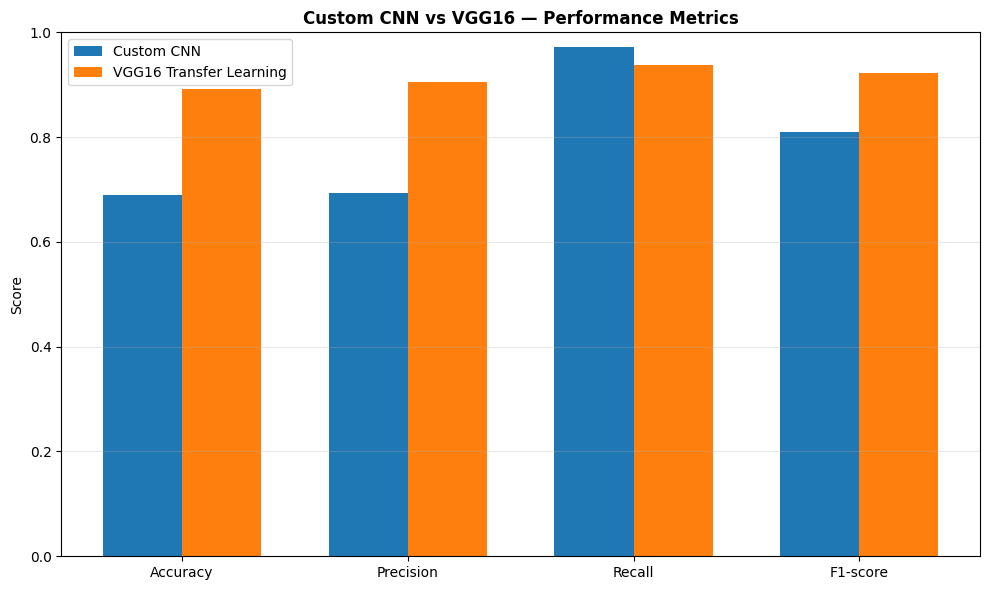

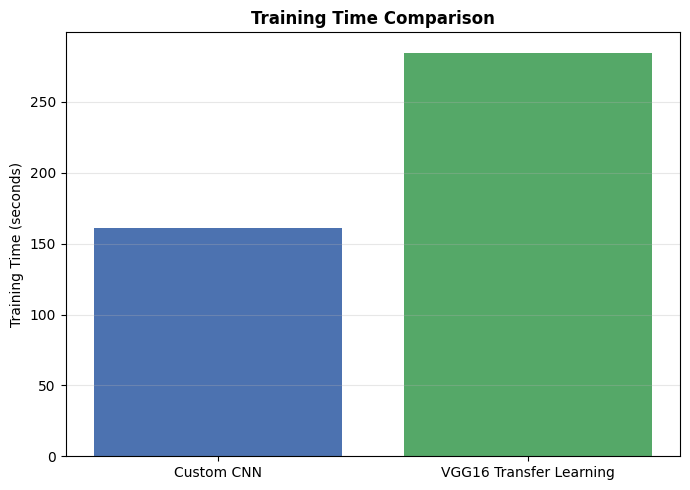

🏆 Higher Test Accuracy: VGG16 Transfer Learning
🏆 Higher F1-score:      VGG16 Transfer Learning


In [ ]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]
plot_df = df_comparison[df_comparison["Metric"].isin(metrics_to_plot)]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_to_plot))
width = 0.35
ax.bar(x - width/2, plot_df["Custom CNN"], width, label="Custom CNN")
ax.bar(x + width/2, plot_df["VGG16 Transfer Learning"], width, label="VGG16 Transfer Learning")
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Custom CNN vs VGG16 — Performance Metrics", fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

better_acc_model = "Custom CNN" if acc_cnn > acc_vgg else ("VGG16 Transfer Learning" if acc_vgg > acc_cnn else "Tie")
better_f1_model = "Custom CNN" if f1_cnn > f1_vgg else ("VGG16 Transfer Learning" if f1_vgg > f1_cnn else "Tie")
print(f"🏆 Higher Test Accuracy: {better_acc_model}")
print(f"🏆 Higher F1-score:      {better_f1_model}")


## 📚 24. Comparison with Research Paper

### A. What the paper did
- Used the **full BreaKHis** dataset (multiple magnifications).
- Benign vs Malignant classification.
- Compared **VGG16, VGG19, and ResNet50** as fixed feature extractors and fine-tuned models.
- Used a **logistic regression / SVM classifier** on top of extracted CNN features.
- Reported a best **VGG16 transfer-learning accuracy of 92.60%** on a 90%-10% train-test split.

### B. What we implemented
- Used the **BreaKHis 400X subset** (Kaggle) only.
- Benign vs Malignant classification.
- Built a **Custom CNN from scratch** for direct comparison.
- Implemented **VGG16** with a trainable dense classification head (feature extraction + fine-tuning), trained **end-to-end** rather than with a separate logistic-regression classifier.
- Directly compared **Custom CNN vs VGG16** on the same data pipeline.

| Aspect | Research Paper | Our Implementation |
|---|---|---|
| Dataset | Full BreaKHis | BreaKHis 400X subset |
| Magnification | 40X, 100X, 200X, 400X | 400X only |
| Classes | Benign, Malignant | Benign, Malignant |
| Models | VGG16, VGG19, ResNet50 | Custom CNN, VGG16 |
| Training strategy | Train-from-scratch vs transfer learning per model | Custom CNN (scratch) vs VGG16 (transfer learning) |
| Transfer learning | Feature extraction + fine-tuning, external classifier (LR/SVM) | Feature extraction + fine-tuning, end-to-end dense head |
| Evaluation metrics | Accuracy (primary) | Accuracy, Precision, Recall, F1, ROC-AUC |
| Main objective | Compare training strategies across 3 pretrained models | Compare a from-scratch CNN directly against VGG16 transfer learning |

> **Important:** *Our implementation follows the core research question and transfer-learning methodology of the selected paper while adapting the experiment to the smaller 400X subset and the practical requirement of comparing a custom CNN directly against VGG16.* We do **not** claim our results reproduce the paper.


## 🏁 25. Conclusion

The cell below **automatically generates** the conclusion text using the actual computed results — the winning model is never hard-coded.


In [ ]:
overall_better_model = "VGG16 Transfer Learning" if acc_vgg >= acc_cnn else "Custom CNN"
overall_better_f1 = "VGG16 Transfer Learning" if f1_vgg >= f1_cnn else "Custom CNN"
time_comparison = ("VGG16 took longer to train than the Custom CNN"
                    if vgg_training_time > cnn_training_time
                    else "the Custom CNN took longer to train than VGG16")
transfer_helped = acc_vgg > acc_cnn

conclusion_text = f"""
Based on our experimental results, the **{overall_better_model}** achieved the higher overall
test accuracy ({acc_vgg:.4f} for VGG16 vs {acc_cnn:.4f} for the Custom CNN), and the
**{overall_better_f1}** achieved the higher F1-score ({f1_vgg:.4f} for VGG16 vs {f1_cnn:.4f}
for the Custom CNN).

In terms of training time, {time_comparison}
(Custom CNN: {cnn_training_time:.2f}s vs VGG16: {vgg_training_time:.2f}s), and VGG16 has
substantially more total parameters ({vgg_total_params:,}) compared to the Custom CNN
({total_params:,}), reflecting its greater representational capacity and computational cost.

{"Transfer learning appears to have helped in this experiment, consistent with the direction of the selected research paper's findings (fine-tuned VGG16 achieving strong performance)." if transfer_helped else "In this particular experiment, the Custom CNN performed comparably to or better than VGG16 transfer learning, which differs from the general trend reported in the selected research paper and may be attributable to the smaller dataset subset, different training configuration, or the limited number of epochs used here."}

These findings should be interpreted in the context of the smaller BreaKHis 400X subset used
here, and do not constitute a clinically validated diagnostic result.
"""

print(conclusion_text)



Based on our experimental results, the **VGG16 Transfer Learning** achieved the higher overall
test accuracy (0.8917 for VGG16 vs 0.6899 for the Custom CNN), and the
**VGG16 Transfer Learning** achieved the higher F1-score (0.9214 for VGG16 vs 0.8095
for the Custom CNN).

In terms of training time, VGG16 took longer to train than the Custom CNN
(Custom CNN: 160.80s vs VGG16: 284.84s), and VGG16 has
substantially more total parameters (14,780,481) compared to the Custom CNN
(423,361), reflecting its greater representational capacity and computational cost.

Transfer learning appears to have helped in this experiment, consistent with the direction of the selected research paper's findings (fine-tuned VGG16 achieving strong performance).

These findings should be interpreted in the context of the smaller BreaKHis 400X subset used
here, and do not constitute a clinically validated diagnostic result.



## 📖 26. References

1. Sharma, S., & Mehra, R. (2018). *Breast cancer histology images classification: Training from scratch or transfer learning?* ICT Express. https://doi.org/10.1016/j.icte.2018.10.007
   https://www.sciencedirect.com/science/article/pii/S2405959518304934
2. BreaKHis 400X Dataset (Kaggle). https://www.kaggle.com/datasets/forderation/breakhis-400x
3. Spanhol, F. A., Oliveira, L. S., Petitjean, C., & Heutte, L. (2016). *A Dataset for Breast Cancer Histopathological Image Classification.* IEEE Transactions on Biomedical Engineering. (Original BreaKHis dataset paper)
4. TensorFlow/Keras VGG16 Documentation: https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16
5. Scikit-learn Documentation: https://scikit-learn.org/stable/documentation.html


## 🖋️ 27. Declaration

I hereby declare that this implementation was prepared for **Practical Assignment 1** and that the results presented are generated from the experiments performed in this notebook.

**Student Name:** Sneha Chaurasia

**Roll Number:** 202401110046

**Date:** 20/8/2026

**Subject:** Generative AI Lab
